# Stat153/248 - Lecture 7 and 8 Finger Tapping Exercise

This is the (in progress) notebook from our exercise in class. We will continue with this during Lecture 8.

In [83]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from matplotlib import pyplot as plt
import glob
import os

In [85]:
data_dir = '/Users/liberty/Documents/Berkeley/Teaching/Stat153_data/Finger_Tap/'
csv_files = glob.glob(f'{data_dir}/*.csv')

In [86]:
import seaborn as sns

<Axes: xlabel='tap_index', ylabel='t_seconds'>

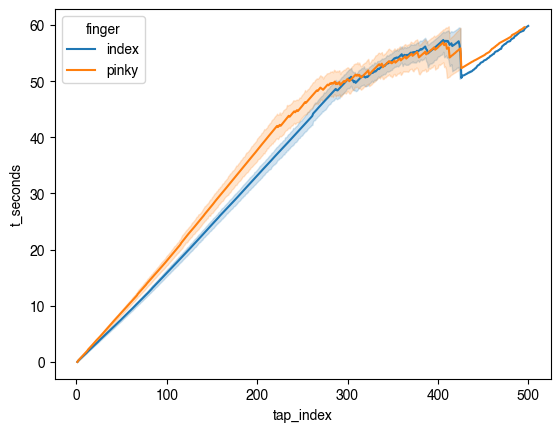

In [87]:
sns.lineplot(x='tap_index', y='t_seconds', hue='finger', data=df_all)

<Axes: xlabel='dominant_hand', ylabel='dt_seconds'>

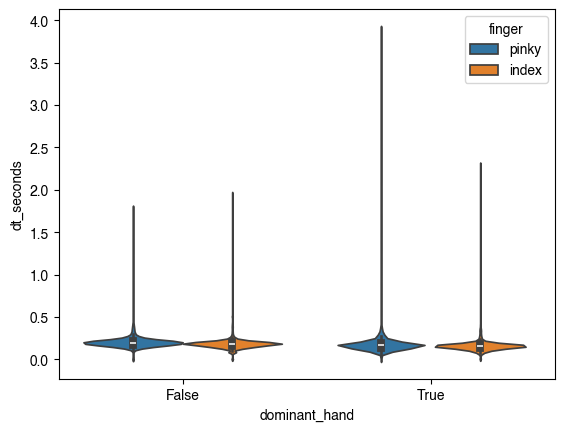

In [19]:
sns.violinplot(data=df_all, x='dominant_hand', y='dt_seconds', hue='finger')
#plt.gca().set_ylim([0, 0.4])

In [20]:
summary_df

,subj,hand,finger,handedness,dominant_hand,ntaps
0,0,left,index,left,True,330
1,1,right,pinky,right,True,371
2,2,left,pinky,right,False,296
3,3,left,index,right,False,308
4,4,right,index,left,False,301
...,...,...,...,...,...,...
96,96,left,pinky,right,False,314
97,97,left,index,left,True,355
98,98,left,index,right,False,305
99,99,right,index,right,True,387


In [26]:
import statsmodels.api as sm

df2 = pd.get_dummies(summary_df, columns = ['finger', 'hand'], drop_first=True)

In [27]:
df2

,subj,handedness,dominant_hand,ntaps,finger_pinky,hand_right
0,0,left,True,330,False,False
1,1,right,True,371,True,True
2,2,right,False,296,True,False
3,3,right,False,308,False,False
4,4,left,False,301,False,True
...,...,...,...,...,...,...
96,96,right,False,314,True,False
97,97,left,True,355,False,False
98,98,right,False,305,False,False
99,99,right,True,387,False,True


In [29]:
y = df2['ntaps']
X = df2[['finger_pinky', 'dominant_hand']]
X = sm.add_constant(X)
X = X.astype(float)
print(X)

     const  finger_pinky  dominant_hand
0      1.0           0.0            1.0
1      1.0           1.0            1.0
2      1.0           1.0            0.0
3      1.0           0.0            0.0
4      1.0           0.0            0.0
..     ...           ...            ...
96     1.0           1.0            0.0
97     1.0           0.0            1.0
98     1.0           0.0            0.0
99     1.0           0.0            1.0
100    1.0           0.0            1.0

[101 rows x 3 columns]


In [30]:
print(y)

0      330
1      371
2      296
3      308
4      301
      ... 
96     314
97     355
98     305
99     387
100    347
Name: ntaps, Length: 101, dtype: int64


In [31]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  ntaps   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     17.38
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           3.47e-07
Time:                        08:41:34   Log-Likelihood:                -531.87
No. Observations:                 101   AIC:                             1070.
Df Residuals:                      98   BIC:                             1078.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           323.5174      8.624     37.515

In [39]:
XTX_inv=np.linalg.inv(np.dot(X.T, X))
betas=np.dot(np.dot(XTX_inv, X.T), y)
print(betas)

[323.51735505 -28.24982225  46.70670933]


In [36]:
X.shape

(101, 3)

In [41]:
import statsmodels.formula.api as smf

In [44]:
model = smf.ols(formula="ntaps~ C(dominant_hand) + C(finger)", data=summary_df).fit()

In [45]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  ntaps   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     17.38
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           3.47e-07
Time:                        08:52:19   Log-Likelihood:                -531.87
No. Observations:                 101   AIC:                             1070.
Df Residuals:                      98   BIC:                             1078.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [46]:
model = smf.ols(formula = "ntaps ~ C(dominant_hand)", data=summary_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  ntaps   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     24.12
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           3.58e-06
Time:                        08:55:18   Log-Likelihood:                -536.19
No. Observations:                 101   AIC:                             1076.
Df Residuals:                      99   BIC:                             1082.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [47]:
model = smf.ols(formula = "ntaps ~ C(hand)+C(finger)", data=summary_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  ntaps   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     21.58
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           1.71e-08
Time:                        08:56:55   Log-Likelihood:                -528.77
No. Observations:                 101   AIC:                             1064.
Df Residuals:                      98   BIC:                             1071.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            322.2382      8

<Axes: xlabel='hand', ylabel='count'>

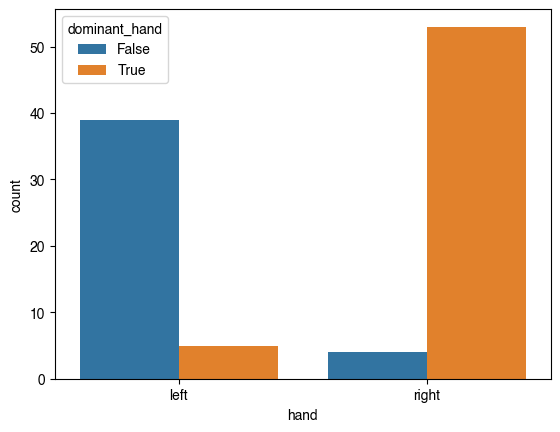

In [50]:
sns.countplot(x='hand', data=summary_df, hue='dominant_hand')

In [51]:
google_form = pd.read_csv('/Users/liberty/Documents/Berkeley/Teaching/Stat153_data/fingertaps_summary.csv')

In [54]:
google_form['How many finger taps did you complete in 60 seconds?']

0     338
1     398
2     364
3     409
4     304
     ... 
60    360
61    271
62    425
63    328
64    424
Name: How many finger taps did you complete in 60 seconds?, Length: 65, dtype: int64

In [55]:
google_form = google_form.rename(columns=lambda c: "ntaps" if "How many finger taps" in c else c)
google_form = google_form.rename(columns=lambda c: "sleep_hrs" if "How much sleep" in c else c)
google_form = google_form.rename(columns=lambda c: "handedness" if "Are you left handed" in c else c)
google_form = google_form.rename(columns=lambda c: "finger" if "Which finger" in c else c)
google_form = google_form.rename(columns=lambda c: "hand" if "Which hand" in c else c)
google_form = google_form.rename(columns=lambda c: "gamer" if "play video games" in c else c)
google_form = google_form.rename(columns=lambda c: "sport" if "sport" in c else c)

google_form['dominant_hand'] = google_form['handedness'] == google_form['hand']

google_form

,Timestamp,ntaps,handedness,finger,hand,gamer,sleep_hrs,sport,dominant_hand
0,2/10/26 9:04,338,Right,Pinky,Left,No,7.00,0,False
1,2/10/26 9:04,398,Right,Index,Right,No,6.00,8,True
2,2/10/26 9:04,364,Right,Index,Right,No,5.00,0,True
3,2/10/26 9:04,409,Right,Pinky,Right,Yes,4.00,7,True
4,2/10/26 9:04,304,Right,Index,Left,No,5.83,2,False
...,...,...,...,...,...,...,...,...,...
60,2/10/26 9:05,360,Right,Index,Right,No,6.00,5,True
61,2/10/26 9:05,271,Left,Pinky,Right,No,6.00,4,False
62,2/10/26 9:05,425,Right,Index,Right,No,8.00,4,True
63,2/10/26 9:06,328,Right,Index,Left,No,8.50,7,False


                            OLS Regression Results                            
Dep. Variable:                  ntaps   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                     9.826
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           2.23e-05
Time:                        09:06:11   Log-Likelihood:                -348.16
No. Observations:                  65   AIC:                             704.3
Df Residuals:                      61   BIC:                             713.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [59]:
model = smf.ols(formula = "ntaps ~ C(finger) + C(dominant_hand) + sport", data=google_form).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  ntaps   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     9.064
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           4.75e-05
Time:                        09:07:59   Log-Likelihood:                -348.99
No. Observations:                  65   AIC:                             706.0
Df Residuals:                      61   BIC:                             714.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [62]:
model = smf.ols(formula = "ntaps ~ C(finger) + C(dominant_hand) + C(gamer)", data=google_form).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  ntaps   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     12.69
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           1.51e-06
Time:                        09:10:22   Log-Likelihood:                -345.21
No. Observations:                  65   AIC:                             698.4
Df Residuals:                      61   BIC:                             707.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

<Axes: xlabel='dominant_hand', ylabel='ntaps'>

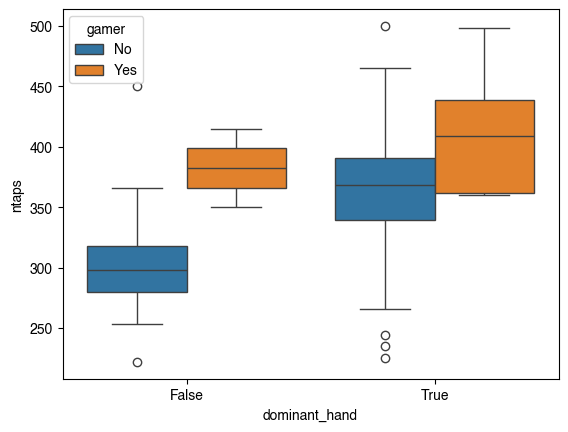

In [64]:
sns.boxplot(x='dominant_hand', y='ntaps', hue='gamer', data=google_form)

In [65]:
df_all

,tap_index,t_seconds,dt_seconds,subj,finger,hand,handedness,dominant_hand
0,1,0.000,0.000,0,index,left,left,True
1,2,0.149,0.149,0,index,left,left,True
2,3,0.316,0.167,0,index,left,left,True
3,4,0.483,0.167,0,index,left,left,True
4,5,0.634,0.151,0,index,left,left,True
...,...,...,...,...,...,...,...,...
34108,343,58.878,0.188,100,index,right,right,True
34109,344,59.058,0.180,100,index,right,right,True
34110,345,59.229,0.171,100,index,right,right,True
34111,346,59.411,0.182,100,index,right,right,True


In [69]:
bin_size = 10 # in seconds
df_all['time_bin'] = (df_all['t_seconds'] // bin_size).astype(int)
df_all

df_bins = ( df_all.groupby(['subj', 'handedness', 'finger','hand','dominant_hand', 'time_bin'])
            .size()
            .reset_index(name='taps_bin')
          )
df_bins

,subj,handedness,finger,hand,dominant_hand,time_bin,taps_bin
0,0,left,index,left,True,0,66
1,0,left,index,left,True,1,54
2,0,left,index,left,True,2,52
3,0,left,index,left,True,3,55
4,0,left,index,left,True,4,50
...,...,...,...,...,...,...,...
598,100,right,index,right,True,1,60
599,100,right,index,right,True,2,57
600,100,right,index,right,True,3,57
601,100,right,index,right,True,4,56


In [70]:
df_bins.to_csv('/Users/liberty/Documents/Berkeley/Teaching/Stat153_data/df_bins.csv')

<Axes: xlabel='time_bin', ylabel='taps_bin'>

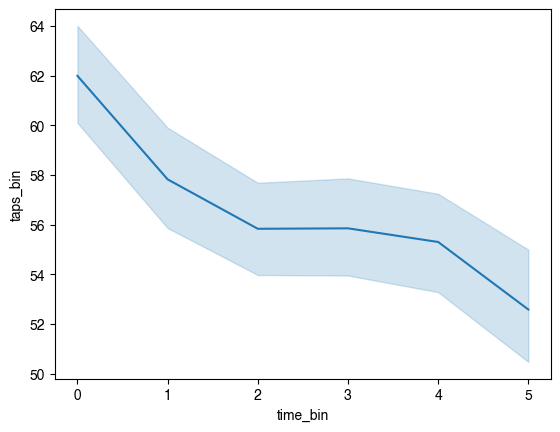

In [74]:
sns.lineplot(x='time_bin', y='taps_bin', data=df_bins)

<Axes: xlabel='time_bin', ylabel='taps_bin'>

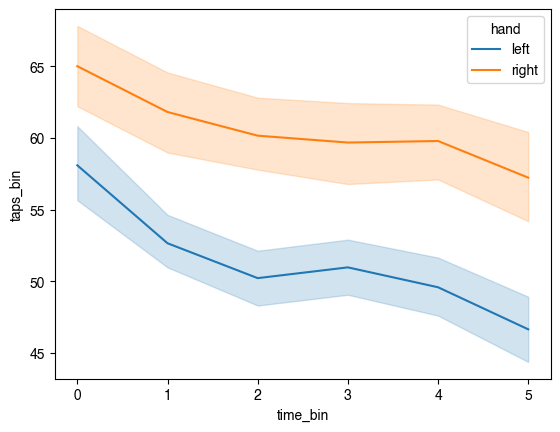

In [76]:
sns.lineplot(x='time_bin', y='taps_bin', hue='hand', data=df_bins)

<Axes: xlabel='time_bin', ylabel='taps_bin'>

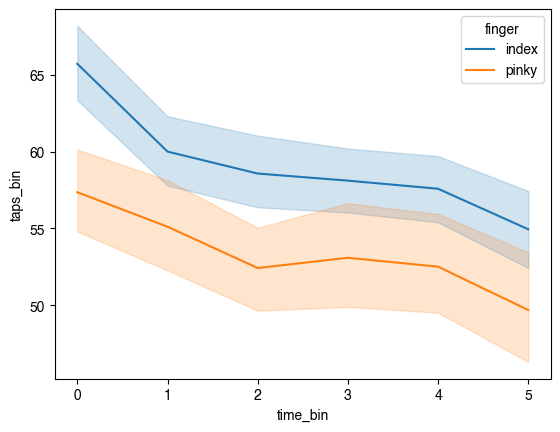

In [77]:
sns.lineplot(x='time_bin', y='taps_bin', hue='finger', data=df_bins)

In [78]:
model=smf.ols('taps_bin ~ time_bin', data=df_bins).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               taps_bin   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     39.96
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           5.06e-10
Time:                        09:27:53   Log-Likelihood:                -2264.1
No. Observations:                 603   AIC:                             4532.
Df Residuals:                     601   BIC:                             4541.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     60.4624      0.746     81.047      0.0

In [80]:
model = smf.ols('taps_bin ~ time_bin*C(finger) + C(dominant_hand)', data=df_bins).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               taps_bin   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     58.82
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           7.05e-42
Time:                        09:30:12   Log-Likelihood:                -2183.5
No. Observations:                 603   AIC:                             4377.
Df Residuals:                     598   BIC:                             4399.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         